In [1]:
from utlis import *
from config import *
from data import *
from model import *
from trainer import *
from sae import *
from transformers import BertTokenizer
from torch.utils.data import DataLoader
from torch.optim import AdamW


/Users/jesanahammed/Math498-Project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from analysis import *

In [3]:
device = get_device()
datacon = DatasetConfig("/Users/jesanahammed/Desktop/IMDB/IMDB Dataset.csv", "csv", "review", "sentiment", 128)
modelcon = ModelConfig("bert-base-uncased", None)
tokenizer = BertTokenizer.from_pretrained(modelcon.model_name)

loader = DatasetLoader(datacon, tokenizer)
dataset, num_labels, label_map = loader.load()
print(num_labels)

modelcon.num_labels = num_labels

Map: 100%|██████████| 10000/10000 [00:01<00:00, 9857.82 examples/s]

2


In [4]:
trainingcon = TrainingConfig(32, 2, 2e-5)

In [5]:
train_loader = DataLoader(dataset["train"], batch_size=trainingcon.batch_size)
test_loader = DataLoader(dataset["test"], batch_size=trainingcon.batch_size)

In [6]:
model = BERTClassifier(modelcon, device)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6718.67it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [7]:
optimizer = AdamW(model.model.parameters(), lr=trainingcon.lr)

In [7]:
trainer = Trainer(model.model, optimizer, device, datacon)

In [8]:
trainer.train(train_loader, trainingcon.epochs)

Epoch 0: Loss 0.3111
Epoch 1: Loss 0.1808


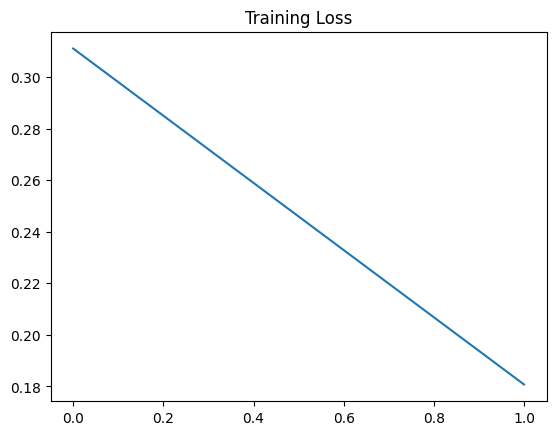

In [11]:
trainer.plot_loss()

In [12]:
trainer.evaluate(test_loader)

Confusion Matrix:
 [[4378  651]
 [ 409 4562]]


In [13]:
model.save("outputs/models/bert")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]


In [8]:
model.load("outputs/models/bert")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 5993.35it/s]


In [9]:
saeconfig = SAEConfig(
    768, 5000, 1e-3, 32, 10, model, train_loader, 5000, device
)

In [10]:
ts = trainsae(saeconfig)

In [11]:
sae, H_norm, Y = ts.train_sae()

100%|██████████| 157/157 [00:00<00:00, 345.59it/s]


Epoch 0: Loss 30.2415


100%|██████████| 157/157 [00:00<00:00, 392.75it/s]


Epoch 1: Loss 8.7571


100%|██████████| 157/157 [00:00<00:00, 397.47it/s]


...

Epoch 7: Loss 4.8902


100%|██████████| 157/157 [00:00<00:00, 396.46it/s]


Epoch 8: Loss 4.8896


100%|██████████| 157/157 [00:00<00:00, 384.01it/s]

Epoch 9: Loss 5.0543


In [12]:
Z = get_feature_activations(sae, H_norm, device)

In [13]:
def plot(Z):
    

    vals = Z.detach().cpu().numpy().flatten()

    plt.figure(figsize=(6,4))
    plt.hist(vals, bins=100)
    plt.title("Activation Distribution")
    plt.xlabel("Activation value")
    plt.ylabel("Frequency")
    plt.show()

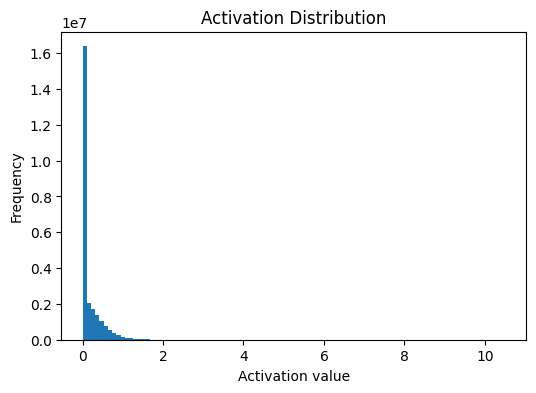

In [14]:
plot(Z)

In [15]:
importance = compute_feature_importance(Z, Y)
print(importance)
# top_features = get_top_features(importance, k=10)

# print("Top features:", top_features)

tensor([0.0042, 0.0010, 0.0074,  ..., 0.0129, 0.0160, 0.0009])


In [16]:
p_values = compute_ttest(Z, Y)
reg_weights = compute_logistic_importance(Z, Y)

In [17]:
score = combine_scores(importance, p_values, reg_weights)

In [18]:
top_features = get_top_features(score, k=10)

print("Top features:", top_features)

Top features: tensor([3652, 2315, 4076,  501, 4218, 2285, 2686, 3324, 1401,  225])


In [21]:
for f in top_features:
    show_top_texts(f, Z, dataset, text_col=datacon.text_column)


===== Feature 3652 =====



KeyError: 'review'